# Importing the necessary libraries and loading the dataset

In [12]:
import numpy as np
import pandas as pd
df=pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Distributions of target variable

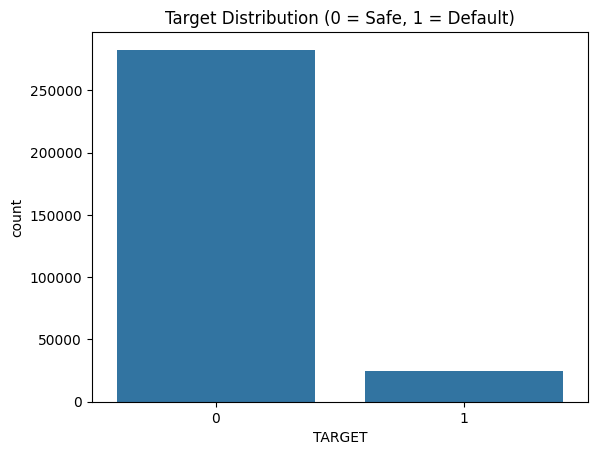

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution (0 = Safe, 1 = Default)")
plt.show()

Dataset is highly imbalanced, with significantly more non-default cases than default cases.

# Income vs Target

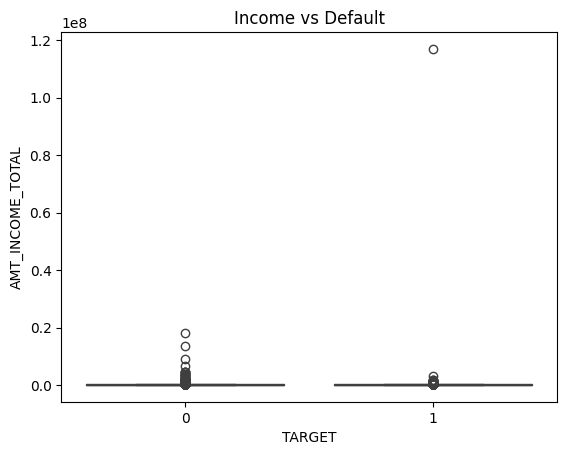

In [15]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.title("Income vs Default")
plt.show()

Income distribution appears similar across default and non-default customers, with significant presence of outliers.

# Credit Amount vs Target 

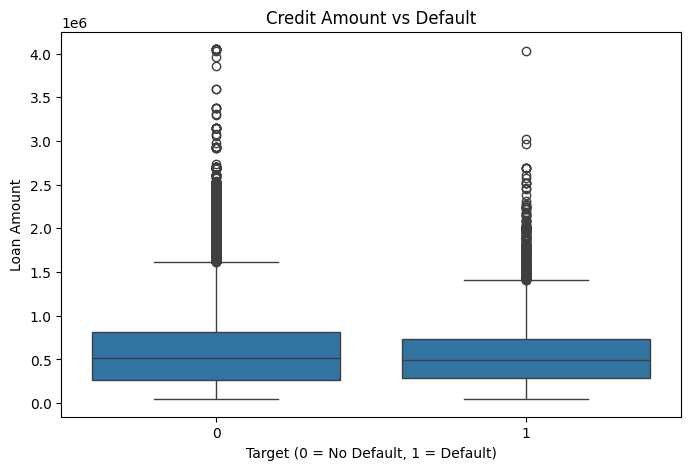

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df)
plt.title("Credit Amount vs Default")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Loan Amount")
plt.show()

Loan amount does not significantly differ between default and non-default customers.

# Age Analysis

In [17]:
df['AGE'] = df['DAYS_BIRTH'] / -365

C:\Users\srina\AppData\Local\Temp\ipykernel_58148\3850861371.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df.groupby(age_bins)['TARGET'].mean()


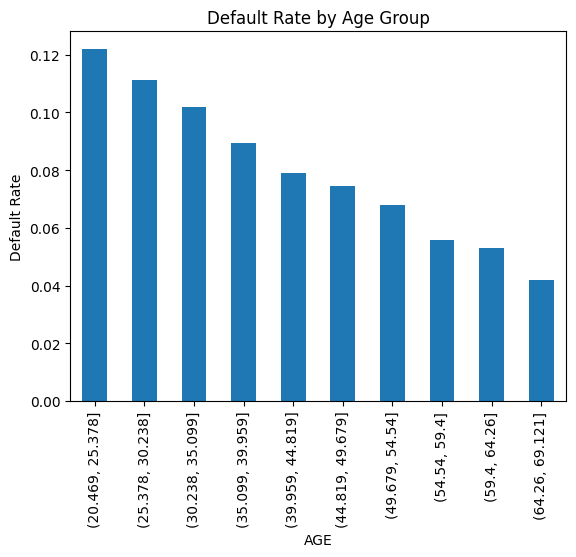

In [23]:
age_bins = pd.cut(df['AGE'], bins=10)
default_rate = df.groupby(age_bins)['TARGET'].mean()
default_rate.plot(kind='bar')
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.show()

Younger customers appear to have a relatively higher likelihood of default, although this should be confirmed using normalized proportions due to class imbalance.

# Employment Duration

C:\Users\srina\AppData\Local\Temp\ipykernel_58148\1087169932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


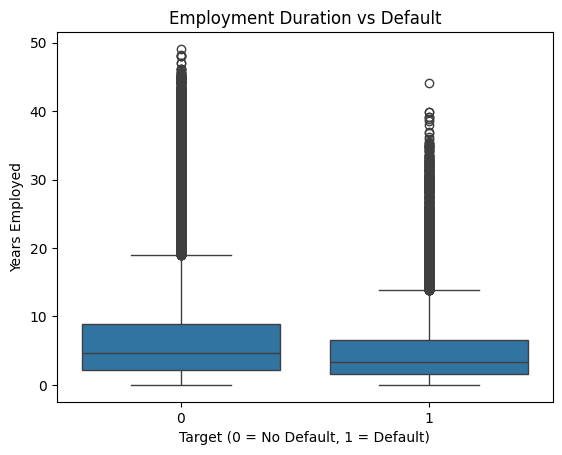

In [24]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# 2. Convert to years
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

# 3. Plot graph
sns.boxplot(x='TARGET', y='YEARS_EMPLOYED', data=df)
plt.title("Employment Duration vs Default")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Years Employed")
plt.show()

Customers with shorter employment duration show a slightly higher likelihood of default, although the difference is not very strong.

In [20]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

# Adding feature for better feature feature engineering

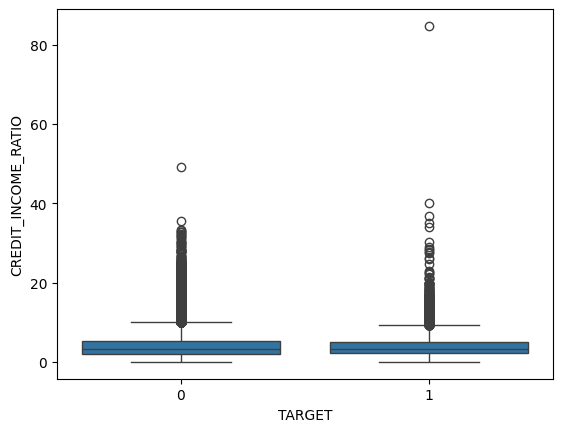

In [33]:
target_corr = df.select_dtypes(include=['number']).corr()['TARGET'].sort_values(ascending=False)
target_corr.head(10)
target_corr.tail(10)
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
sns.boxplot(x='TARGET', y='CREDIT_INCOME_RATIO', data=df)
plt.show()

Customers with higher credit-to-income ratios show a slightly higher likelihood of default, indicating this feature may be useful for prediction.